Import Libraries and Setup

In [3]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

print("Libraries imported successfully!")

Libraries imported successfully!


Load Dataset

In [4]:
# Load the dataset
df = pd.read_csv('../data/zambia_climate_30yr.csv')
df['Date'] = pd.to_datetime(df['Date'])

print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"Date range: {df['Date'].min()} to {df['Date'].max()}")
print(f"Number of cities: {df['City'].nunique()}")
print(f"Cities: {df['City'].unique().tolist()}")

Dataset loaded successfully!
Shape: (109590, 17)
Columns: ['Date', 'City', 'Latitude', 'Longitude', 'Elevation_m', 'Rainfall_mm', 'Temp_C', 'Soil_Moisture_Pct', 'River_Level_m', 'Year', 'Month', 'DayOfYear', 'Rainfall_7d_avg', 'Rainfall_30d_avg', 'Rainfall_90d_avg', 'Drought_Event', 'Flood_Event']
Date range: 1996-01-01 00:00:00 to 2026-01-01 00:00:00
Number of cities: 10
Cities: ['Chipata', 'Choma', 'Kasama', 'Kitwe', 'Livingstone', 'Lusaka', 'Mazabuka', 'Mongu', 'Ndola', 'Solwezi']


Display First Rows

In [5]:
# Display first few rows
df.head(10)

,Date,City,Latitude,Longitude,Elevation_m,Rainfall_mm,Temp_C,Soil_Moisture_Pct,River_Level_m,Year,Month,DayOfYear,Rainfall_7d_avg,Rainfall_30d_avg,Rainfall_90d_avg,Drought_Event,Flood_Event
0,1996-01-01,Chipata,-13.63,32.64,1150,9.42,20.1,40.9,0.0,1996,1,1,9.420000,9.420000,9.420000,0,0
1,1996-01-02,Chipata,-13.63,32.64,1150,7.35,19.3,37.4,0.0,1996,1,2,8.385000,8.385000,8.385000,0,0
2,1996-01-03,Chipata,-13.63,32.64,1150,6.57,18.7,36.2,0.0,1996,1,3,7.780000,7.780000,7.780000,0,0
3,1996-01-04,Chipata,-13.63,32.64,1150,15.48,18.8,52.2,0.0,1996,1,4,9.705000,9.705000,9.705000,0,0
4,1996-01-05,Chipata,-13.63,32.64,1150,3.05,21.0,29.2,0.0,1996,1,5,8.374000,8.374000,8.374000,0,0
5,1996-01-06,Chipata,-13.63,32.64,1150,5.48,19.0,34.2,0.0,1996,1,6,7.891667,7.891667,7.891667,0,0
6,1996-01-07,Chipata,-13.63,32.64,1150,10.29,18.3,43.0,0.0,1996,1,7,8.234286,8.234286,8.234286,0,0
7,1996-01-08,Chipata,-13.63,32.64,1150,18.46,19.9,57.3,0.0,1996,1,8,9.525714,9.512500,9.512500,0,0
8,1996-01-09,Chipata,-13.63,32.64,1150,3.00,21.1,29.1,0.0,1996,1,9,8.904286,8.788889,8.788889,0,0
9,1996-01-10,Chipata,-13.63,32.64,1150,12.07,20.1,45.7,0.0,1996,1,10,9.690000,9.117000,9.117000,0,0


Basic Statistics

In [6]:
# Basic statistics
df.describe()

,Date,Latitude,Longitude,Elevation_m,Rainfall_mm,Temp_C,Soil_Moisture_Pct,River_Level_m,Year,Month,DayOfYear,Rainfall_7d_avg,Rainfall_30d_avg,Rainfall_90d_avg,Drought_Event,Flood_Event
count,109590,109590.000000,109590.000000,109590.000000,109590.000000,109590.000000,109590.000000,109590.000000,109590.000000,109590.000000,109590.000000,109590.000000,109590.000000,109590.000000,109590.000000,109590.000000
mean,2011-01-01 00:00:00,-14.295040,27.910500,1209.100000,3.448562,21.773972,29.305456,0.545790,2010.501049,6.522219,183.116981,3.449346,3.450163,3.457511,0.337056,0.003769
min,1996-01-01 00:00:00,-17.844100,23.129000,986.000000,0.000000,11.300000,19.900000,0.000000,1996.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2003-07-02 00:00:00,-15.850000,26.400000,1050.000000,0.000000,18.500000,23.400000,0.000000,2003.000000,4.000000,92.000000,0.000000,0.022667,0.057556,0.000000,0.000000
50%,2011-01-01 00:00:00,-14.442500,27.976500,1250.000000,0.430000,21.800000,25.100000,0.000000,2011.000000,7.000000,183.000000,1.396429,2.069833,2.542667,0.000000,0.000000
75%,2018-07-03 00:00:00,-12.809100,28.650000,1300.000000,4.620000,25.000000,31.900000,0.000000,2018.000000,10.000000,274.000000,5.735714,6.023000,5.785217,1.000000,0.000000
max,2026-01-01 00:00:00,-10.211400,32.640000,1400.000000,512.590000,33.900000,100.000000,12.000000,2026.000000,12.000000,366.000000,84.657143,70.040000,70.040000,1.000000,1.000000
std,NaN,2.213499,2.532696,142.476227,8.328987,4.019546,10.230305,1.116136,8.656746,3.449022,105.453495,4.836805,4.073262,3.529842,0.472706,0.061273


Check Missing Values

In [7]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())
print("\n" + "="*50)
print(f"Total missing values: {df.isnull().sum().sum()}")

Missing values per column:
Date                 0
City                 0
Latitude             0
Longitude            0
Elevation_m          0
Rainfall_mm          0
Temp_C               0
Soil_Moisture_Pct    0
River_Level_m        0
Year                 0
Month                0
DayOfYear            0
Rainfall_7d_avg      0
Rainfall_30d_avg     0
Rainfall_90d_avg     0
Drought_Event        0
Flood_Event          0
dtype: int64

Total missing values: 0


City-wise Statistics

In [8]:
# City-wise statistics
city_stats = df.groupby('City').agg({
    'Rainfall_mm': ['mean', 'max', 'std'],
    'Temp_C': ['mean', 'max', 'min'],
    'Soil_Moisture_Pct': ['mean', 'min'],
    'Drought_Event': 'sum',
    'Flood_Event': 'sum'
}).round(2)

city_stats.columns = ['Rain_Mean', 'Rain_Max', 'Rain_Std', 
                       'Temp_Mean', 'Temp_Max', 'Temp_Min',
                       'Soil_Moisture_Mean', 'Soil_Moisture_Min',
                       'Drought_Events', 'Flood_Events']

city_stats

,Rain_Mean,Rain_Max,Rain_Std,Temp_Mean,Temp_Max,Temp_Min,Soil_Moisture_Mean,Soil_Moisture_Min,Drought_Events,Flood_Events
City,,,,,,,,,,
Chipata,3.28,172.37,7.39,22.39,32.4,13.9,28.85,20.3,3716,46
Choma,2.49,230.00,5.81,21.39,31.1,12.4,27.89,20.7,4046,26
Kasama,4.17,512.59,10.47,20.37,30.0,11.5,30.84,21.3,3432,58
Kitwe,4.66,311.55,11.03,20.37,30.4,11.3,31.59,20.9,3403,63
Livingstone,2.36,177.41,5.18,24.35,33.9,15.4,26.82,19.9,4096,24
Lusaka,2.84,236.83,6.35,21.38,31.4,11.7,28.50,20.8,3852,27
Mazabuka,2.72,234.15,6.18,22.36,31.4,13.3,27.98,20.6,3875,25
Mongu,3.61,250.33,8.34,23.38,32.5,14.4,29.09,20.3,3573,43
Ndola,4.35,268.91,9.42,20.37,29.9,11.6,31.26,21.3,3433,53


Visualize City Characteristics

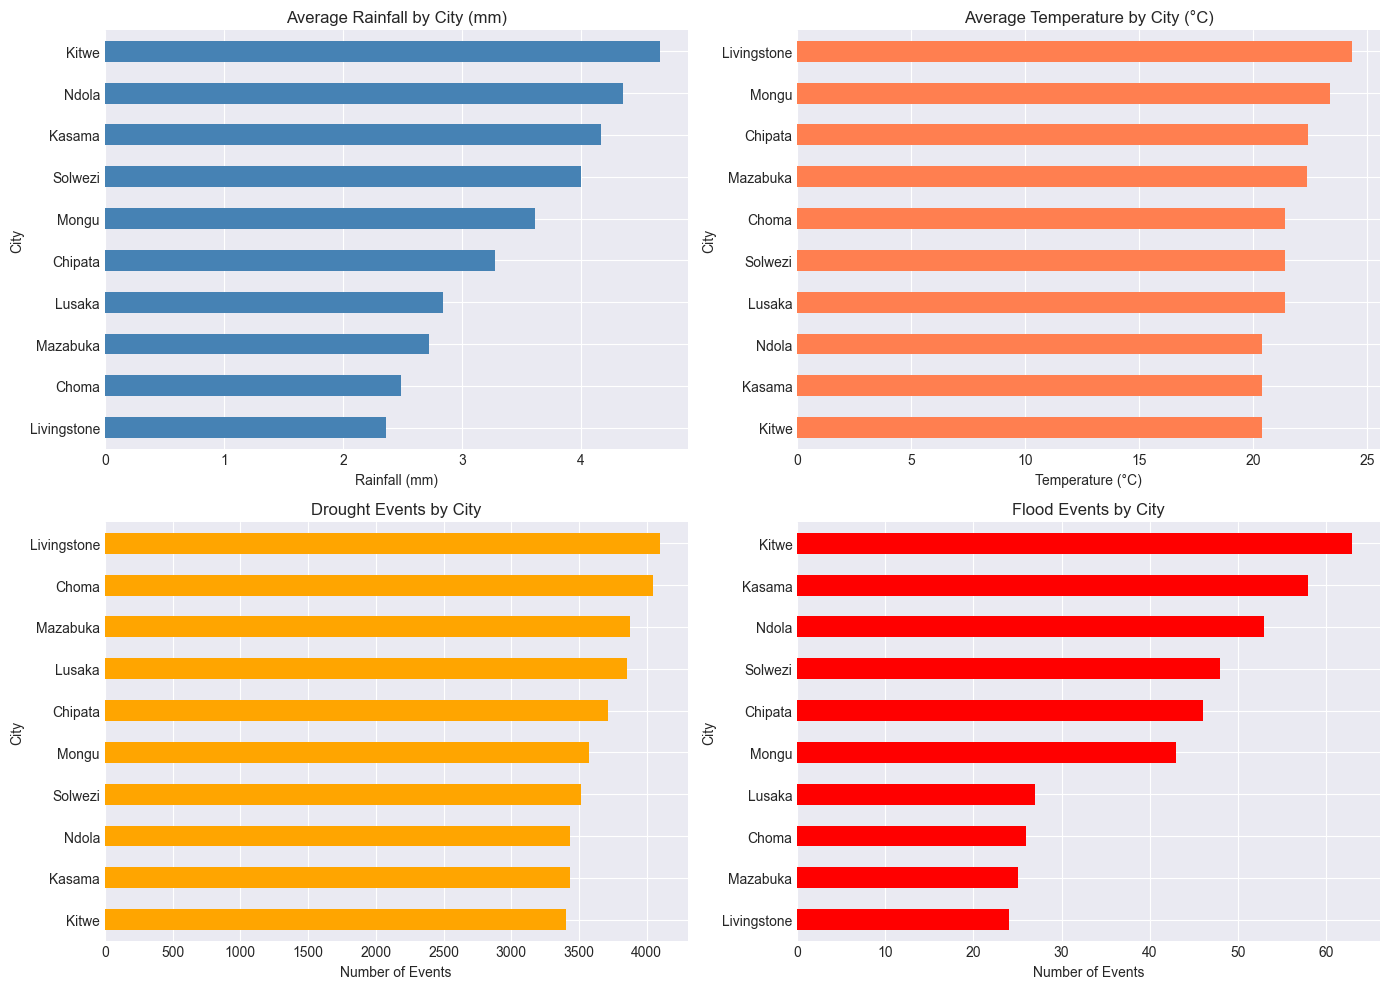

In [9]:
# Visualize city characteristics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Average rainfall by city
city_stats['Rain_Mean'].sort_values().plot(kind='barh', ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Average Rainfall by City (mm)', fontsize=12)
axes[0,0].set_xlabel('Rainfall (mm)')

# Average temperature by city
city_stats['Temp_Mean'].sort_values().plot(kind='barh', ax=axes[0,1], color='coral')
axes[0,1].set_title('Average Temperature by City (°C)', fontsize=12)
axes[0,1].set_xlabel('Temperature (°C)')

# Drought events by city
city_stats['Drought_Events'].sort_values().plot(kind='barh', ax=axes[1,0], color='orange')
axes[1,0].set_title('Drought Events by City', fontsize=12)
axes[1,0].set_xlabel('Number of Events')

# Flood events by city
city_stats['Flood_Events'].sort_values().plot(kind='barh', ax=axes[1,1], color='red')
axes[1,1].set_title('Flood Events by City', fontsize=12)
axes[1,1].set_xlabel('Number of Events')

plt.tight_layout()
plt.show()

Monthly Patterns

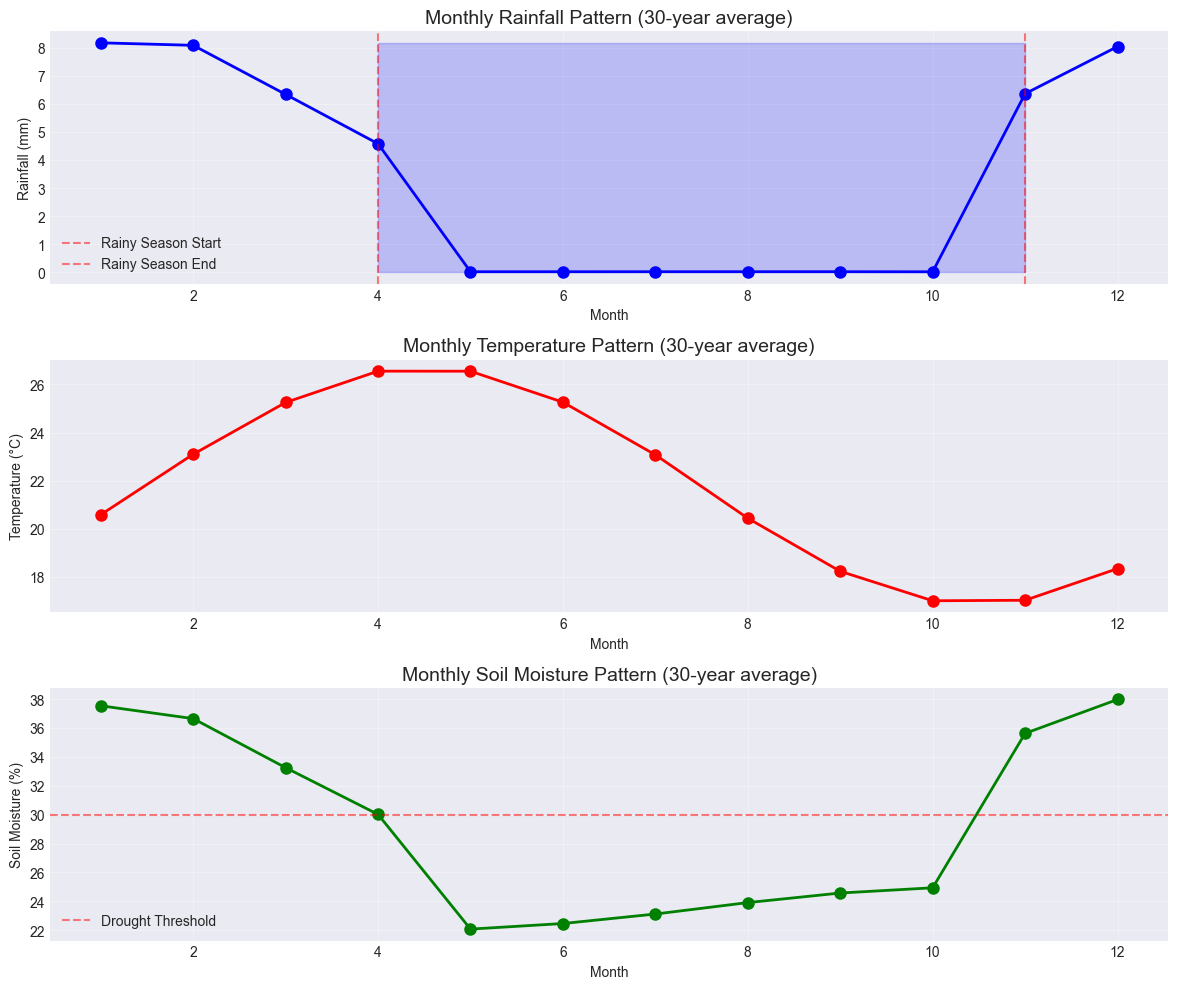

In [10]:
# Monthly patterns
monthly_patterns = df.groupby('Month').agg({
    'Rainfall_mm': 'mean',
    'Temp_C': 'mean',
    'Soil_Moisture_Pct': 'mean'
}).reset_index()

fig, axes = plt.subplots(3, 1, figsize=(12, 10))

# Rainfall monthly pattern
axes[0].plot(monthly_patterns['Month'], monthly_patterns['Rainfall_mm'], 'o-', linewidth=2, markersize=8, color='blue')
axes[0].axvline(x=11, color='red', linestyle='--', alpha=0.5, label='Rainy Season Start')
axes[0].axvline(x=4, color='red', linestyle='--', alpha=0.5, label='Rainy Season End')
axes[0].fill_between([11, 4], 0, monthly_patterns['Rainfall_mm'].max(), alpha=0.2, color='blue')
axes[0].set_title('Monthly Rainfall Pattern (30-year average)', fontsize=14)
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Rainfall (mm)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Temperature monthly pattern
axes[1].plot(monthly_patterns['Month'], monthly_patterns['Temp_C'], 'o-', linewidth=2, markersize=8, color='red')
axes[1].set_title('Monthly Temperature Pattern (30-year average)', fontsize=14)
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Temperature (°C)')
axes[1].grid(True, alpha=0.3)

# Soil moisture monthly pattern
axes[2].plot(monthly_patterns['Month'], monthly_patterns['Soil_Moisture_Pct'], 'o-', linewidth=2, markersize=8, color='green')
axes[2].axhline(y=30, color='red', linestyle='--', alpha=0.5, label='Drought Threshold')
axes[2].set_title('Monthly Soil Moisture Pattern (30-year average)', fontsize=14)
axes[2].set_xlabel('Month')
axes[2].set_ylabel('Soil Moisture (%)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Yearly Trends

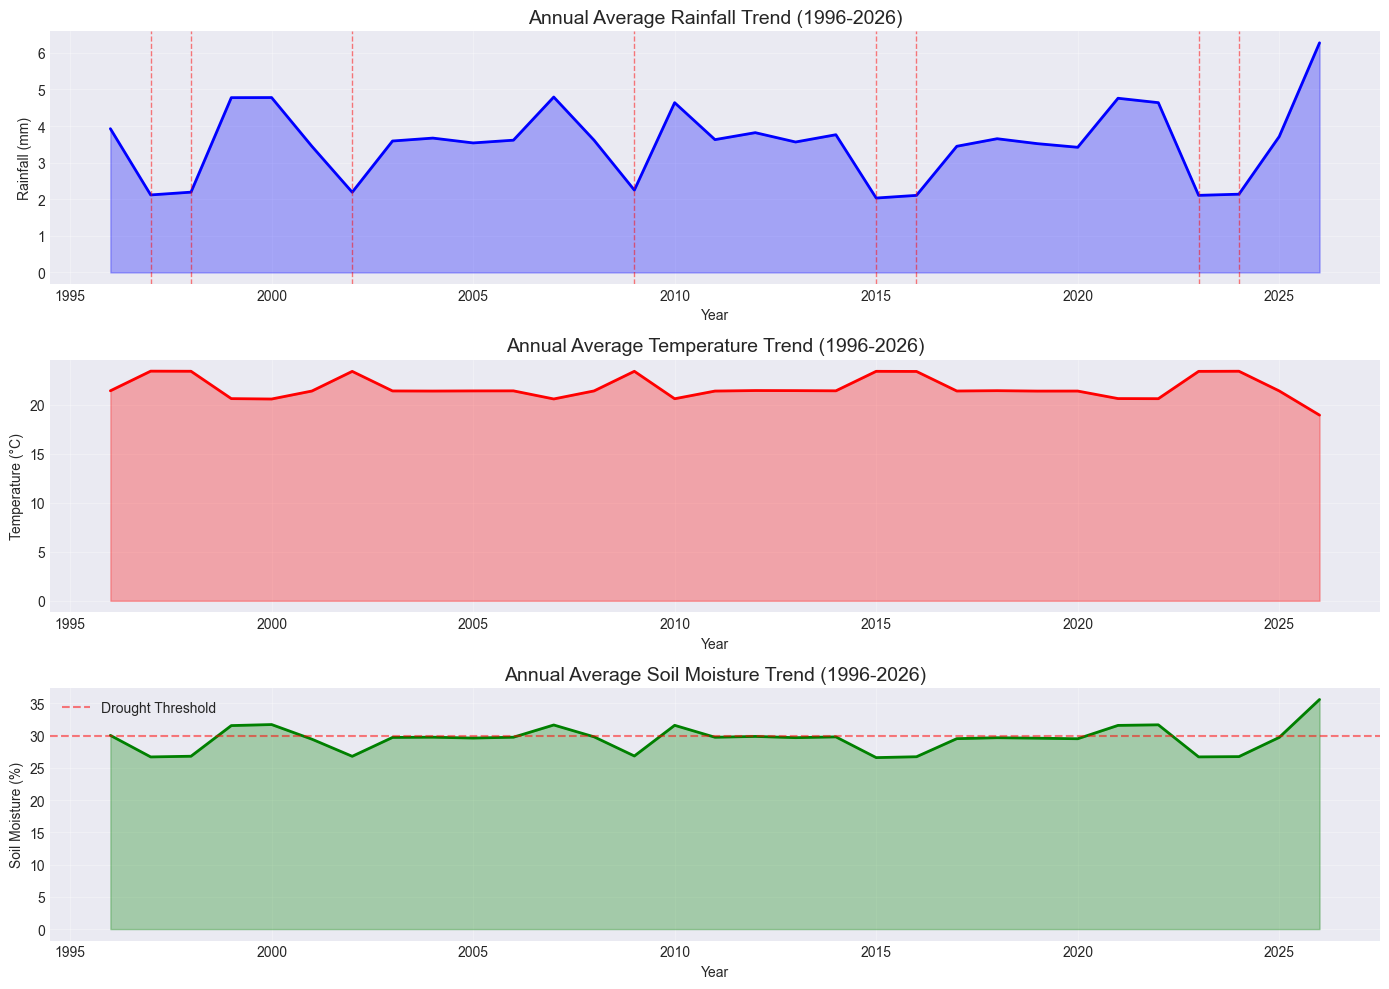

In [11]:
# Yearly trends (rolling averages)
yearly_trends = df.groupby('Year').agg({
    'Rainfall_mm': 'mean',
    'Temp_C': 'mean',
    'Soil_Moisture_Pct': 'mean'
}).reset_index()

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Rainfall trend
axes[0].plot(yearly_trends['Year'], yearly_trends['Rainfall_mm'], linewidth=2, color='blue')
axes[0].fill_between(yearly_trends['Year'], yearly_trends['Rainfall_mm'], alpha=0.3, color='blue')
axes[0].set_title('Annual Average Rainfall Trend (1996-2026)', fontsize=14)
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Rainfall (mm)')
axes[0].grid(True, alpha=0.3)

# Highlight El Niño years
el_nino_years = [1997, 1998, 2002, 2009, 2015, 2016, 2023, 2024]
for year in el_nino_years:
    axes[0].axvline(x=year, color='red', linestyle='--', alpha=0.5, linewidth=1)

# Temperature trend
axes[1].plot(yearly_trends['Year'], yearly_trends['Temp_C'], linewidth=2, color='red')
axes[1].fill_between(yearly_trends['Year'], yearly_trends['Temp_C'], alpha=0.3, color='red')
axes[1].set_title('Annual Average Temperature Trend (1996-2026)', fontsize=14)
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Temperature (°C)')
axes[1].grid(True, alpha=0.3)

# Soil moisture trend
axes[2].plot(yearly_trends['Year'], yearly_trends['Soil_Moisture_Pct'], linewidth=2, color='green')
axes[2].fill_between(yearly_trends['Year'], yearly_trends['Soil_Moisture_Pct'], alpha=0.3, color='green')
axes[2].axhline(y=30, color='red', linestyle='--', alpha=0.5, label='Drought Threshold')
axes[2].set_title('Annual Average Soil Moisture Trend (1996-2026)', fontsize=14)
axes[2].set_xlabel('Year')
axes[2].set_ylabel('Soil Moisture (%)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Correlation Analysis

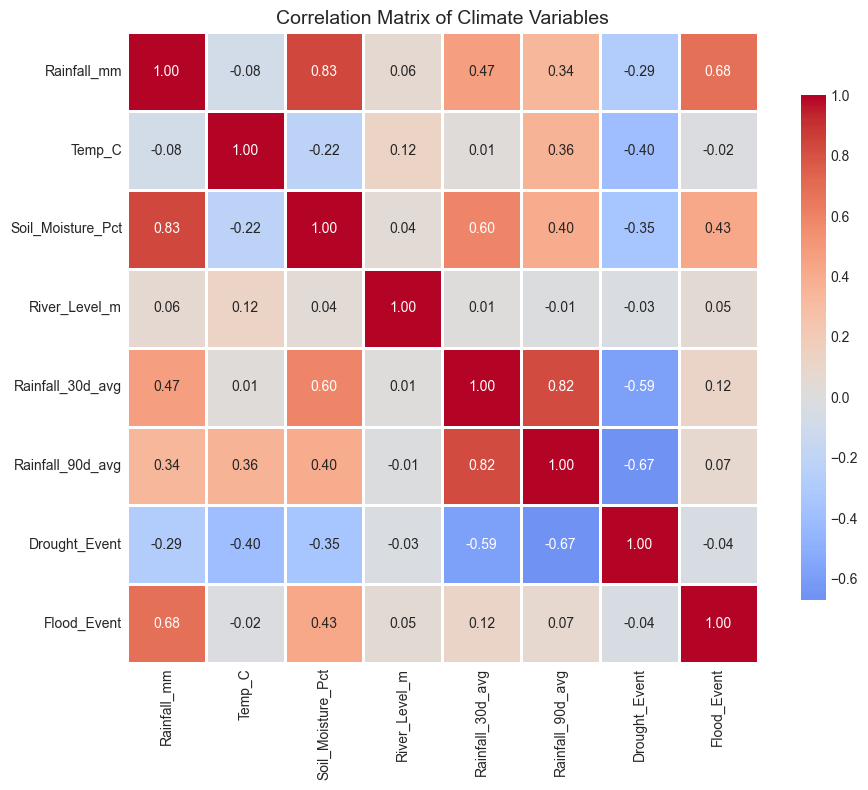

In [12]:
# Correlation matrix
numeric_cols = ['Rainfall_mm', 'Temp_C', 'Soil_Moisture_Pct', 'River_Level_m', 
                 'Rainfall_30d_avg', 'Rainfall_90d_avg', 'Drought_Event', 'Flood_Event']

correlation_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix of Climate Variables', fontsize=14)
plt.tight_layout()
plt.show()

Feature Correlations

In [13]:
# Feature importance analysis
print("Key Correlations with Events:")
print("\nFlood Events Correlations:")
flood_corr = correlation_matrix['Flood_Event'].sort_values(ascending=False)
print(flood_corr)

print("\nDrought Events Correlations:")
drought_corr = correlation_matrix['Drought_Event'].sort_values(ascending=False)
print(drought_corr)

Key Correlations with Events:

Flood Events Correlations:
Flood_Event          1.000000
Rainfall_mm          0.683485
Soil_Moisture_Pct    0.425019
Rainfall_30d_avg     0.116361
Rainfall_90d_avg     0.073427
River_Level_m        0.047005
Temp_C              -0.015907
Drought_Event       -0.043855
Name: Flood_Event, dtype: float64

Drought Events Correlations:
Drought_Event        1.000000
River_Level_m       -0.026441
Flood_Event         -0.043855
Rainfall_mm         -0.285648
Soil_Moisture_Pct   -0.345273
Temp_C              -0.403621
Rainfall_30d_avg    -0.586751
Rainfall_90d_avg    -0.671394
Name: Drought_Event, dtype: float64


Interactive Time Series Plot

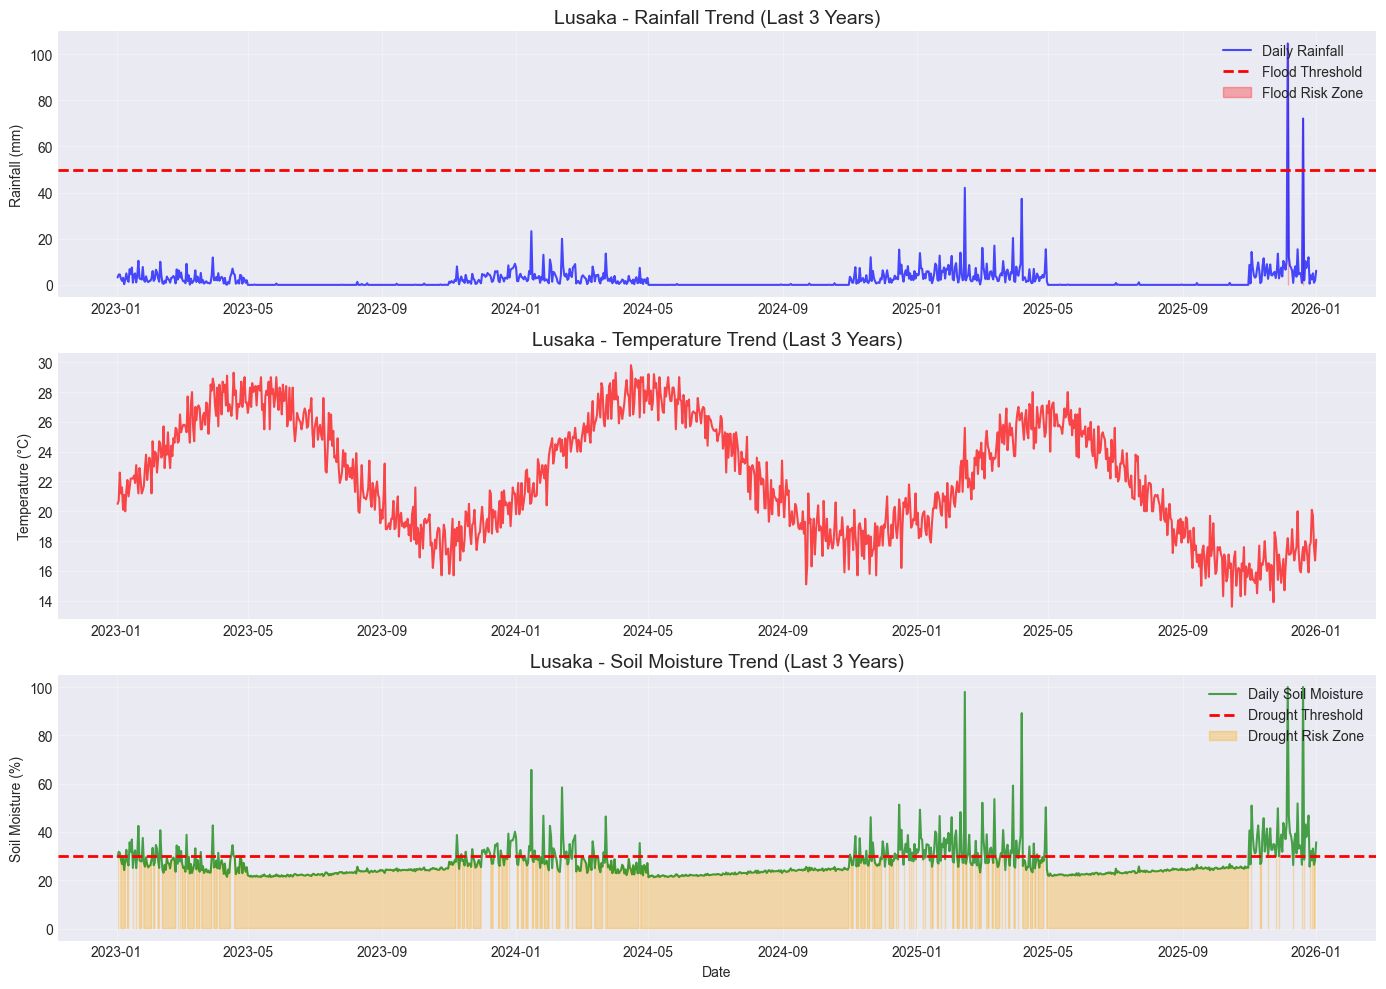

In [15]:
# Time series visualization for a specific city
city_to_plot = 'Lusaka'
city_data = df[df['City'] == city_to_plot].copy()

# Filter last 3 years for better visibility
city_data_recent = city_data[city_data['Date'] > '2023-01-01']

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Rainfall
axes[0].plot(city_data_recent['Date'], city_data_recent['Rainfall_mm'], 
             linewidth=1.5, color='blue', alpha=0.7, label='Daily Rainfall')
axes[0].axhline(y=50, color='red', linestyle='--', linewidth=2, label='Flood Threshold')
axes[0].fill_between(city_data_recent['Date'], city_data_recent['Rainfall_mm'], 
                      where=(city_data_recent['Rainfall_mm'] > 50), 
                      color='red', alpha=0.3, label='Flood Risk Zone')
axes[0].set_title(f'{city_to_plot} - Rainfall Trend (Last 3 Years)', fontsize=14)
axes[0].set_ylabel('Rainfall (mm)')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

# Temperature
axes[1].plot(city_data_recent['Date'], city_data_recent['Temp_C'], 
             linewidth=1.5, color='red', alpha=0.7)
axes[1].set_title(f'{city_to_plot} - Temperature Trend (Last 3 Years)', fontsize=14)
axes[1].set_ylabel('Temperature (°C)')
axes[1].grid(True, alpha=0.3)

# Soil Moisture
axes[2].plot(city_data_recent['Date'], city_data_recent['Soil_Moisture_Pct'], 
             linewidth=1.5, color='green', alpha=0.7, label='Daily Soil Moisture')
axes[2].axhline(y=30, color='red', linestyle='--', linewidth=2, label='Drought Threshold')
axes[2].fill_between(city_data_recent['Date'], city_data_recent['Soil_Moisture_Pct'], 
                      where=(city_data_recent['Soil_Moisture_Pct'] < 30), 
                      color='orange', alpha=0.3, label='Drought Risk Zone')
axes[2].set_title(f'{city_to_plot} - Soil Moisture Trend (Last 3 Years)', fontsize=14)
axes[2].set_xlabel('Date')
axes[2].set_ylabel('Soil Moisture (%)')
axes[2].legend(loc='upper right')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Distribution Analysis

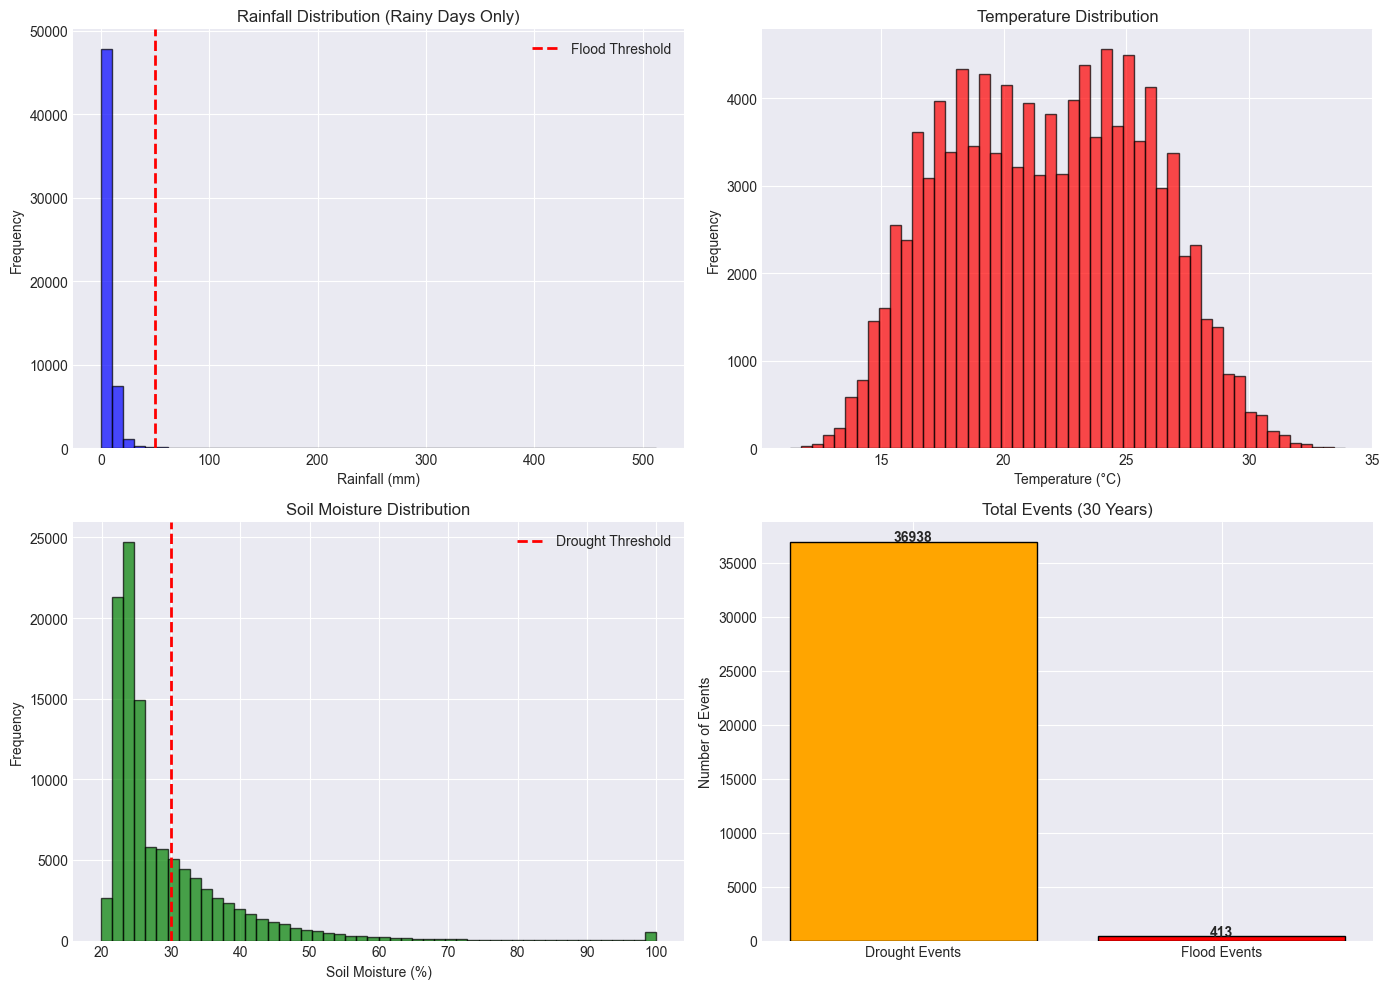

In [17]:
# Distribution analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Rainfall distribution
df[df['Rainfall_mm'] > 0]['Rainfall_mm'].hist(bins=50, ax=axes[0,0], color='blue', alpha=0.7, edgecolor='black')
axes[0,0].set_title('Rainfall Distribution (Rainy Days Only)', fontsize=12)
axes[0,0].set_xlabel('Rainfall (mm)')
axes[0,0].set_ylabel('Frequency')
axes[0,0].axvline(x=50, color='red', linestyle='--', linewidth=2, label='Flood Threshold')
axes[0,0].legend()

# Temperature distribution
df['Temp_C'].hist(bins=50, ax=axes[0,1], color='red', alpha=0.7, edgecolor='black')
axes[0,1].set_title('Temperature Distribution', fontsize=12)
axes[0,1].set_xlabel('Temperature (°C)')
axes[0,1].set_ylabel('Frequency')

# Soil moisture distribution
df['Soil_Moisture_Pct'].hist(bins=50, ax=axes[1,0], color='green', alpha=0.7, edgecolor='black')
axes[1,0].set_title('Soil Moisture Distribution', fontsize=12)
axes[1,0].set_xlabel('Soil Moisture (%)')
axes[1,0].set_ylabel('Frequency')
axes[1,0].axvline(x=30, color='red', linestyle='--', linewidth=2, label='Drought Threshold')
axes[1,0].legend()

# Events distribution
event_counts = df.groupby('City')[['Drought_Event', 'Flood_Event']].sum().sum()
event_labels = ['Drought Events', 'Flood Events']
event_values = [event_counts['Drought_Event'], event_counts['Flood_Event']]
axes[1,1].bar(event_labels, event_values, color=['orange', 'red'], edgecolor='black')
axes[1,1].set_title('Total Events (30 Years)', fontsize=12)
axes[1,1].set_ylabel('Number of Events')
for i, v in enumerate(event_values):
    axes[1,1].text(i, v + 50, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

Event Analysis

In [18]:
# Analyze conditions during flood events
flood_events = df[df['Flood_Event'] == 1]
drought_events = df[df['Drought_Event'] == 1]

print("="*60)
print("Flood Event Analysis")
print("="*60)
print(f"Total flood events: {len(flood_events)}")
print(f"Average rainfall during floods: {flood_events['Rainfall_mm'].mean():.2f} mm")
print(f"Maximum rainfall: {flood_events['Rainfall_mm'].max():.2f} mm")
print(f"Average temperature: {flood_events['Temp_C'].mean():.1f}°C")
print(f"Average soil moisture: {flood_events['Soil_Moisture_Pct'].mean():.1f}%")

print("\n" + "="*60)
print("Drought Event Analysis")
print("="*60)
print(f"Total drought events: {len(drought_events)}")
print(f"Average rainfall during droughts: {drought_events['Rainfall_mm'].mean():.2f} mm")
print(f"Average temperature: {drought_events['Temp_C'].mean():.1f}°C")
print(f"Average soil moisture: {drought_events['Soil_Moisture_Pct'].mean():.1f}%")

Flood Event Analysis
Total flood events: 413
Average rainfall during floods: 96.01 mm
Maximum rainfall: 512.59 mm
Average temperature: 20.7°C
Average soil moisture: 100.0%

Drought Event Analysis
Total drought events: 36938
Average rainfall during droughts: 0.11 mm
Average temperature: 19.5°C
Average soil moisture: 24.4%


Monthly Distribution of Events

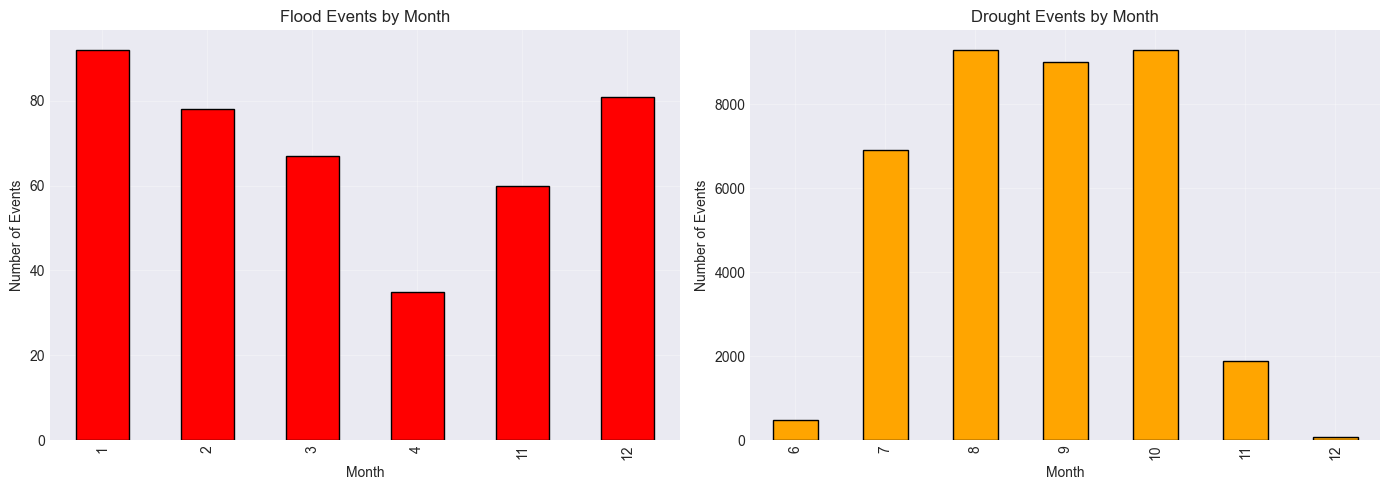

In [19]:
# Monthly distribution of events
flood_by_month = flood_events.groupby('Month').size()
drought_by_month = drought_events.groupby('Month').size()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Flood events by month
flood_by_month.plot(kind='bar', ax=axes[0], color='red', edgecolor='black')
axes[0].set_title('Flood Events by Month', fontsize=12)
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Number of Events')
axes[0].grid(True, alpha=0.3)

# Drought events by month
drought_by_month.plot(kind='bar', ax=axes[1], color='orange', edgecolor='black')
axes[1].set_title('Drought Events by Month', fontsize=12)
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Number of Events')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Summary Statistics

In [20]:
# Comprehensive summary
print("="*60)
print("ZAMBIA CLIMATE DATA SUMMARY (1996-2026)")
print("="*60)

print(f"\n📊 Dataset Overview:")
print(f"  • Total records: {len(df):,}")
print(f"  • Time span: {df['Date'].min().year} - {df['Date'].max().year}")
print(f"  • Cities covered: {df['City'].nunique()}")
print(f"  • Average daily rainfall: {df['Rainfall_mm'].mean():.2f} mm")
print(f"  • Average temperature: {df['Temp_C'].mean():.1f}°C")
print(f"  • Average soil moisture: {df['Soil_Moisture_Pct'].mean():.1f}%")

print(f"\n⚠️ Event Statistics:")
print(f"  • Total drought events: {df['Drought_Event'].sum():,}")
print(f"  • Total flood events: {df['Flood_Event'].sum():,}")
print(f"  • Drought frequency: {df['Drought_Event'].mean()*100:.2f}%")
print(f"  • Flood frequency: {df['Flood_Event'].mean()*100:.2f}%")

print(f"\n🌧️ Extreme Events:")
print(f"  • Maximum daily rainfall: {df['Rainfall_mm'].max():.2f} mm")
print(f"  • Minimum temperature: {df['Temp_C'].min():.1f}°C")
print(f"  • Maximum temperature: {df['Temp_C'].max():.1f}°C")
print(f"  • Minimum soil moisture: {df['Soil_Moisture_Pct'].min():.1f}%")

print(f"\n🏙️ Most Affected Cities:")
city_events = df.groupby('City')[['Drought_Event', 'Flood_Event']].sum()
print(f"  • Most droughts: {city_events['Drought_Event'].idxmax()} ({city_events['Drought_Event'].max():,} events)")
print(f"  • Most floods: {city_events['Flood_Event'].idxmax()} ({city_events['Flood_Event'].max():,} events)")

print("\n" + "="*60)
print("Data exploration complete! Ready for model training.")
print("="*60)

ZAMBIA CLIMATE DATA SUMMARY (1996-2026)

📊 Dataset Overview:
  • Total records: 109,590
  • Time span: 1996 - 2026
  • Cities covered: 10
  • Average daily rainfall: 3.45 mm
  • Average temperature: 21.8°C
  • Average soil moisture: 29.3%

⚠️ Event Statistics:
  • Total drought events: 36,938
  • Total flood events: 413
  • Drought frequency: 33.71%
  • Flood frequency: 0.38%

🌧️ Extreme Events:
  • Maximum daily rainfall: 512.59 mm
  • Minimum temperature: 11.3°C
  • Maximum temperature: 33.9°C
  • Minimum soil moisture: 19.9%

🏙️ Most Affected Cities:
  • Most droughts: Livingstone (4,096 events)
  • Most floods: Kitwe (63 events)

Data exploration complete! Ready for model training.
